<a href="https://colab.research.google.com/github/gabrielmprata/seguranca_publica_pwrbi/blob/main/PREP_anuario_seguranca_publica_pwr_bi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img loading="lazy" src="https://cdn.jsdelivr.net/gh/devicons/devicon@latest/icons/python/python-original.svg" width="40" height="40"/> <img src="https://cdn.jsdelivr.net/gh/devicons/devicon@latest/icons/pandas/pandas-original-wordmark.svg" width="40" height="40"/>   <img loading="lazy" src="https://cdn.jsdelivr.net/gh/devicons/devicon@latest/icons/plotly/plotly-original-wordmark.svg" width="40" height="40"/>

---

>
**Dev**: Gabriel Prata
>
**Data**: 22/04/2026
>
**Última modificação**: 22/04/2026
>
**Contexto**: *Preparar os Dados abertos de segurança pública do Estado do Rio de Janeiro.*
>
---

Pré-processamento dos dados, para serem utilizados em um painel elaborado em Power BI.
>
<img loading="lazy" src="https://img.icons8.com/?size=100&id=3sGOUDo9nJ4k&format=png&color=000000" width="40" height="40"/>

>
![Badge em Desenvolvimento](http://img.shields.io/static/v1?label=STATUS&message=EM%20DESENVOLVIMENTO&color=GREEN&style=for-the-badge)

![Badge versao](http://img.shields.io/static/v1?label=Ver.&message=v1.0&color=red&style=for-the-badge&logo=github)

#**<font color=#4c60d6 size="6"> Import libraries**

In [1]:
# Importação de pacotes
import pandas as pd
import numpy as np
import missingno as ms # para tratamento de missings
import datetime
import re # expressão regulares
import unicodedata

#bibliotecas para visualização de dados
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#compactar
from shutil import copyfileobj
import bz2
# Data e hora
from datetime import datetime, date, time

# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

#**<font color=#4c60d6 size="6"> 1. Coleta de dados**

In [2]:
# importando dataset

# URL de importação
# Conjunto de dados com o registro das ocorrencias
url   = "https://raw.githubusercontent.com/gabrielmprata/Info_seguranca_publica_rj/main/datasets/BaseDPEvolucaoMensalCisp.csv.bz2"
df_ocorrencias = pd.read_csv(url, compression='bz2', encoding = "Latin 1", delimiter=';')

# Conjunto de dados com a unidade territorial das delegacias(CISP)
url2   = "https://raw.githubusercontent.com/gabrielmprata/Info_seguranca_publica_rj/main/datasets/CISP.csv"
df_cisp = pd.read_csv(url2, encoding = "Latin 1", delimiter=';')





---



#**<font color=#4c60d6 size="6"> 2. Análise de Dados Inicial**

###**<font color=#4c60d6> 2.1. Estatísticas Descritivas**

Compreende a organização, o resumo e, descrever os dados, que podem ser expressos em tabelas e gráficos.
>
Veremos a seguir alguns comandos para exibir algumas estatísticas descritivas.


In [3]:
#	Quantidade de atributos e instâncias (linhas/colunas)
df_ocorrencias.shape

(37314, 65)

<font color=#4c60d6> Data frame com 65 atributos(features) e 37.314 tuplas.
>


---





In [4]:
# Exibir os 5 primeiros registros
df_ocorrencias.head(5)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3




---



In [5]:
# Mostra diversas informações do Dataframe em um único comando, e exibir o uso de memória
df_ocorrencias.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37314 entries, 0 to 37313
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        37314 non-null  int64  
 1   mes                         37314 non-null  int64  
 2   ano                         37314 non-null  int64  
 3   mes_ano                     37314 non-null  object 
 4   aisp                        37314 non-null  int64  
 5   risp                        37314 non-null  int64  
 6   munic                       37314 non-null  object 
 7   mcirc                       37314 non-null  int64  
 8   regiao                      37314 non-null  object 
 9   hom_doloso                  37314 non-null  int64  
 10  lesao_corp_morte            37314 non-null  int64  
 11  latrocinio                  37314 non-null  int64  
 12  cvli                        37314 non-null  int64  
 13  hom_por_interv_policial     373

<font color=#4c60d6> Data frame utilizando 24.2 MB de memória.


---

In [6]:
# Quantidade de valores únicos
df_ocorrencias.nunique()

,0
cisp,138
mes,12
ano,24
mes_ano,277
aisp,42
...,...
encontro_ossada,8
pol_militares_mortos_serv,5
pol_civis_mortos_serv,3
registro_ocorrencias,2004




---



In [7]:
# Quantidade de NaN/Missing/Nulls no dataframe
df_ocorrencias.isnull().sum()

,0
cisp,0
mes,0
ano,0
mes_ano,0
aisp,0
...,...
encontro_ossada,0
pol_militares_mortos_serv,0
pol_civis_mortos_serv,0
registro_ocorrencias,0




---



###**<font color=#4c60d6> 2.2. Distribuição dos atributos**

>Nessa etapa, iremos verificar a distribuição dos principais atributos. Para ver se existe a necessidade de tomar alguma ação de transformações na etapa de preparação de dados.


---

In [8]:
df_ocorrencias.describe().round(2)

,cisp,mes,ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,cvli,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
count,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00,...,32668.00,32668.00,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00,37314.00
mean,81.72,6.48,2014.19,20.15,3.87,3791939.01,2.93,0.03,0.10,3.05,...,8.74,0.64,41.31,3.22,0.36,0.02,0.01,0.00,444.01,2.99
std,48.32,3.46,6.63,11.35,2.01,1741131.78,4.33,0.18,0.37,4.44,...,14.81,1.64,39.39,4.16,0.99,0.18,0.13,0.05,398.54,0.12
min,1.00,1.00,2003.00,1.00,1.00,3300100.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
25%,38.00,3.00,2008.00,10.00,2.00,3302601.00,0.00,0.00,0.00,0.00,...,2.00,0.00,14.00,0.00,0.00,0.00,0.00,0.00,106.00,3.00
50%,78.00,6.00,2014.00,20.00,4.00,3304557.00,1.00,0.00,0.00,1.00,...,5.00,0.00,30.00,2.00,0.00,0.00,0.00,0.00,370.00,3.00
75%,125.00,9.00,2020.00,30.00,6.00,3304557.00,4.00,0.00,0.00,4.00,...,11.00,1.00,56.00,5.00,0.00,0.00,0.00,0.00,663.00,3.00
max,168.00,12.00,2026.00,43.00,7.00,9999999.00,43.00,6.00,9.00,43.00,...,419.00,60.00,370.00,191.00,112.00,10.00,4.00,2.00,3185.00,3.00




---



> Distribuição para os principais atributos

In [9]:
df_ocorrencias.cisp.value_counts(normalize=True)

,proportion
cisp,
1,0.007423
4,0.007423
5,0.007423
6,0.007423
7,0.007423
...,...
67,0.004851
70,0.004851
132,0.004851


In [10]:
df_ocorrencias.munic.value_counts(normalize=True)

,proportion
munic,
Rio de Janeiro,0.300075
Niterói,0.037117
São Gonçalo,0.029694
Duque de Caxias,0.029694
Nova Iguaçu,0.022270
...,...
Macaé;Quissamã;Carapebus,0.001742
Itaperuna;São José de Ubá;Cardoso Moreira;Italva,0.001528
Queimados;Japeri,0.000322


In [11]:
df_ocorrencias.regiao.value_counts(normalize=True)

,proportion
regiao,
Interior,0.487538
Capital,0.300075
Baixada Fluminense,0.138152
Grande NiterÃÂÃÂÃÂÃÂ³i,0.069947
Grande Niterói,0.004288


Por acaso, descobrimos um valor do atributo fora do padrão.
>
Iremos tratar na fase do Pré-processamento de dados.

#**<font color=#4c60d6 size="6"> 3. Pré-Processamento de dados**

Após coletar e analisar os dados na etapa anterior, agora é o momento
de limpar, transformar e apresentar melhor os dados.
>
Assim poderemos obter, na próxima etapa, os melhores resultados possíveis nos algoritmos de
Machine Learning, ou simplesmente apresentar dados mais confiáveis para os clientes em soluções de
business intelligence.


---

###**<font color=#4c60d6> 3.1. Limpeza**

De forma resumida, a limpeza consiste na verificação da consistência das informações, correção de possíveis erros de preenchimento ou eliminação de valores desconhecidos, redundantes ou não pertencentes ao domínio.



####**<font color=#4c60d6> 3.1.1 Redundâncias**

Vamos eliminar as colunas que não iremos utilizar em nossas analises.
>
A ideia é ter um dataframe mais leve, e com pouco espaço em disco.

In [12]:
df_ocorrencias.drop([
				            'mes_ano','mcirc','fase'
                    ], axis=1, inplace= True)

In [13]:
df_cisp.drop([
				            'RISP','AISP'
                    ], axis=1, inplace= True)

####**<font color=#4c60d6> 3.1.2 Tratamento de Missings**

Como o DataFrame tem muitos atributos, e muitos deles possuem valores nulos, vou utlizar um método para mostrar apenas os valores nulos e o percentual.
>
1) Converter a função isnull() em um pd.series e depois transformar em DF, assim conseguimos filtrar quais atributos são nulos.
>

In [14]:
#1)
# cria um pd.series
dfnull = df_ocorrencias.isnull().sum()

# Converte series em dataframe
dfnull = (dfnull.to_frame(name="QTD"))

tot = len(df_ocorrencias) #Total de registros no dataset

#Criano o atributo perc, para saber o percentual de registros nulo do atributo
dfnull["perc"] = ((dfnull['QTD']/tot)*100).round(2)

#Mostrar apenas os atributos com valores nulos, ordenando para o com mais linhas nulas
dfnull.query('QTD > 0').sort_values(by='perc', ascending=False)

,QTD,perc
feminicidio,35122,94.13
tentativa_feminicidio,35122,94.13
roubo_bicicleta,17389,46.60
furto_bicicleta,17389,46.60
apf,4646,12.45
posse_drogas,4646,12.45
trafico_drogas,4646,12.45
apreensao_drogas_sem_autor,4646,12.45
cmp,4646,12.45
aaapai,4646,12.45


2) Usar a librarie **MISSINGNO**, que retorna um avisão gráfica bem interessante.

<Axes: >

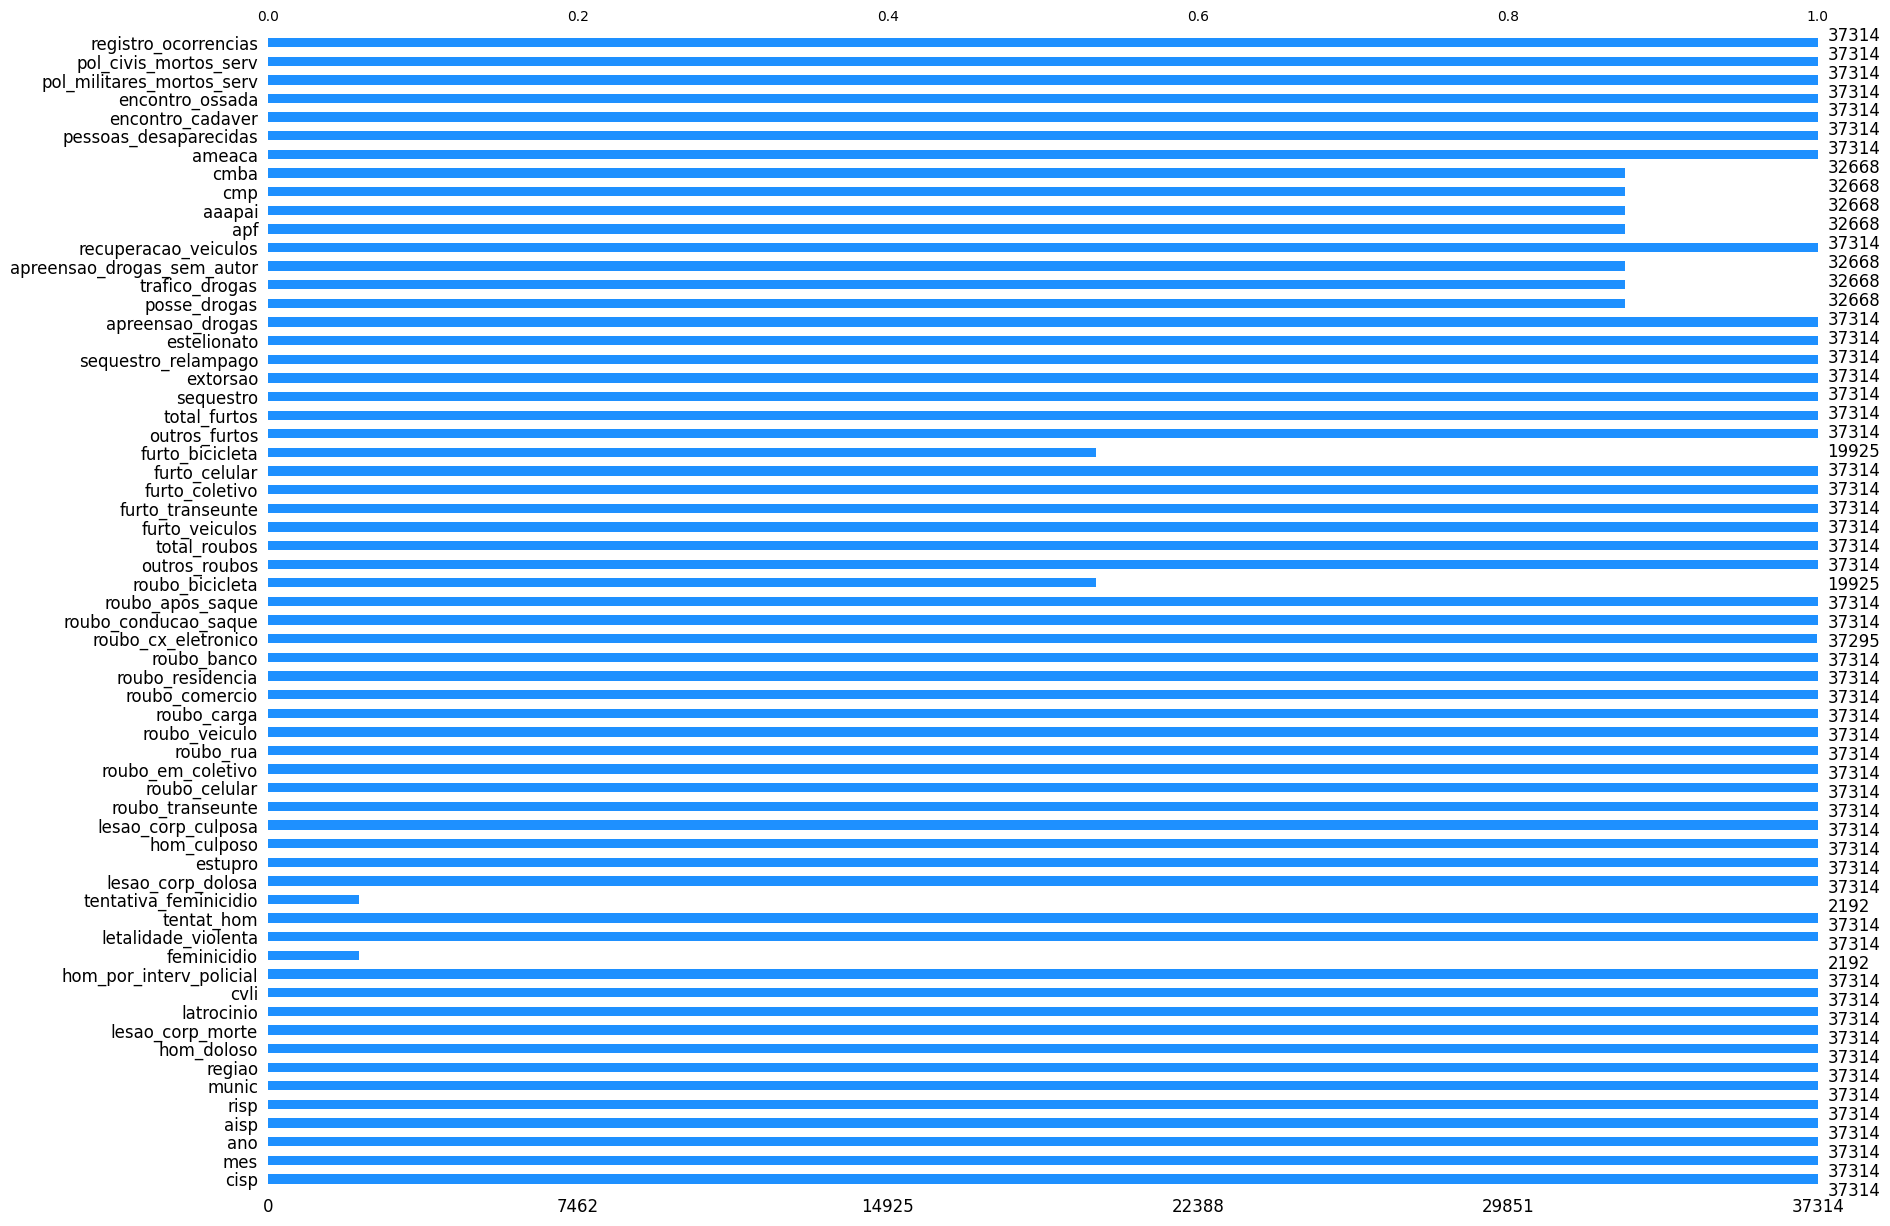

In [15]:
#A Barra mostra a quantidade de registros preenchidos
#Sort ordena do mais preenchido para o menos sort="ascending"
#Sem o sort="ascending", aparece pela ordem dos campos

ms.bar(df_ocorrencias, color="dodgerblue",  figsize=(20,15), fontsize=12)

Como todos os atributos são metricas, preenchido com a quatidade de ocorrencias registradas, iremos preencher todos com zero.

In [16]:
df_ocorrencias['feminicidio'] = df_ocorrencias['feminicidio'].fillna(0)
df_ocorrencias['tentativa_feminicidio'] = df_ocorrencias['tentativa_feminicidio'].fillna(0)
df_ocorrencias['roubo_bicicleta'] = df_ocorrencias['roubo_bicicleta'].fillna(0)
df_ocorrencias['furto_bicicleta'] = df_ocorrencias['furto_bicicleta'].fillna(0)
df_ocorrencias['apf'] = df_ocorrencias['apf'].fillna(0)
df_ocorrencias['posse_drogas'] = df_ocorrencias['posse_drogas'].fillna(0)
df_ocorrencias['trafico_drogas'] = df_ocorrencias['trafico_drogas'].fillna(0)
df_ocorrencias['apreensao_drogas_sem_autor'] = df_ocorrencias['apreensao_drogas_sem_autor'].fillna(0)
df_ocorrencias['cmp'] = df_ocorrencias['cmp'].fillna(0)
df_ocorrencias['aaapai'] = df_ocorrencias['aaapai'].fillna(0)
df_ocorrencias['cmba'] = df_ocorrencias['cmba'].fillna(0)
df_ocorrencias['roubo_cx_eletronico'] = df_ocorrencias['roubo_cx_eletronico'].fillna(0)

<Axes: >

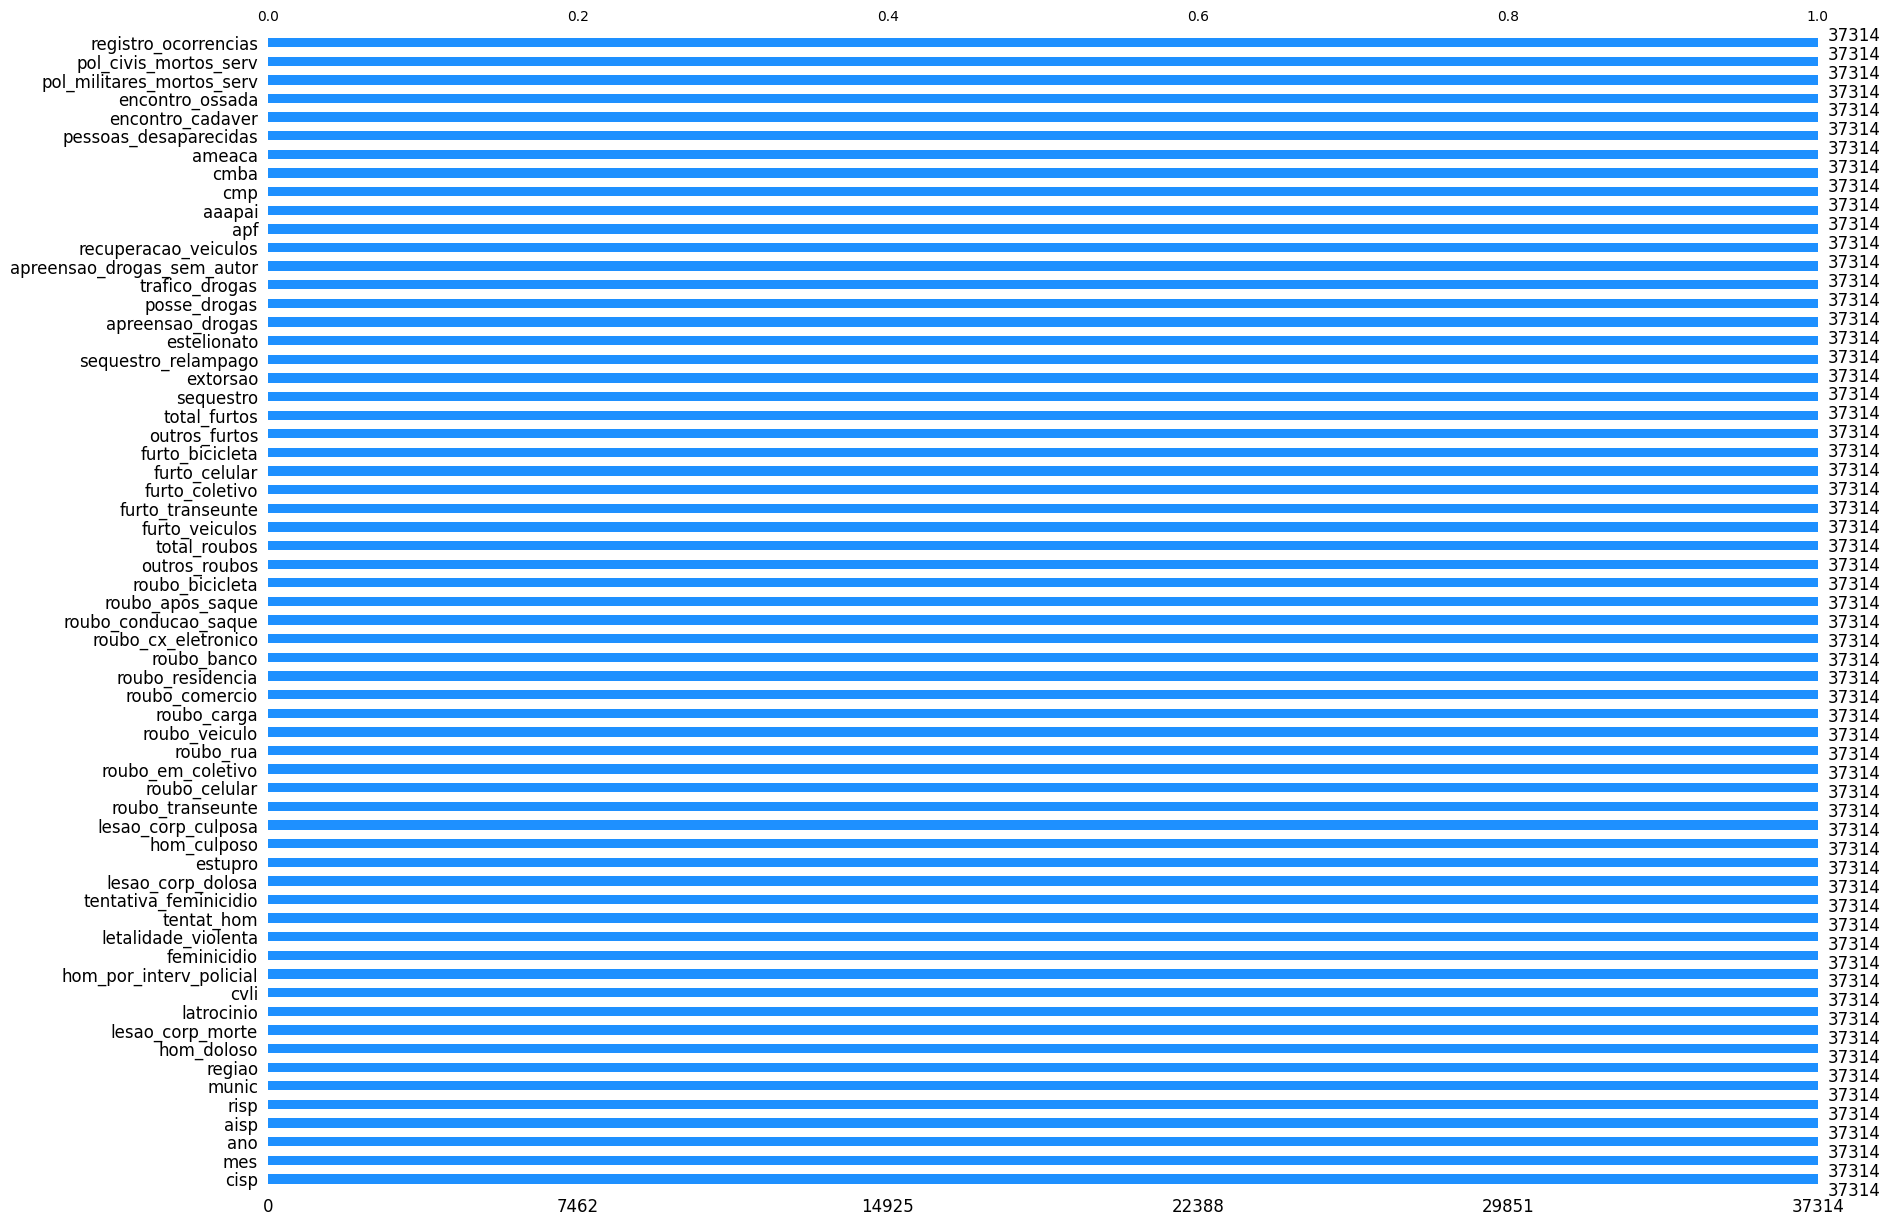

In [17]:

ms.bar(df_ocorrencias, color="dodgerblue",  figsize=(20,15), fontsize=12)

####**<font color=#4c60d6> 3.1.3 Outliers**

In [18]:
import plotly.express as px

fig = px.box(df_ocorrencias, x='ano', y="total_furtos")
fig.update_xaxes(type="category", title=None) # se o type for date, vai respeitar o intervalo


fig.show()

In [19]:
df_ocorrencias[['cisp','ano','mes','munic',
                'furto_veiculos','furto_transeunte','furto_coletivo',
                'furto_celular','furto_bicicleta','outros_furtos']][(df_ocorrencias['total_furtos'] == 1665)]

,cisp,ano,mes,munic,furto_veiculos,furto_transeunte,furto_coletivo,furto_celular,furto_bicicleta,outros_furtos
31709,16,2022,9,Rio de Janeiro,21,103,59,992,5.0,485


In [20]:
df_ocorrencias[['cisp','ano','mes','munic','total_furtos',
                'furto_veiculos','furto_transeunte','furto_coletivo',
                'furto_celular','furto_bicicleta','outros_furtos']][(df_ocorrencias['cisp'] == 16) &
                                                                    (df_ocorrencias['ano'] == 2022)]

,cisp,ano,mes,munic,total_furtos,furto_veiculos,furto_transeunte,furto_coletivo,furto_celular,furto_bicicleta,outros_furtos
30613,16,2022,1,Rio de Janeiro,646,21,42,48,175,6.0,354
30750,16,2022,2,Rio de Janeiro,658,30,71,56,235,13.0,253
30887,16,2022,3,Rio de Janeiro,773,46,56,71,263,11.0,326
31024,16,2022,4,Rio de Janeiro,774,27,57,71,281,7.0,331
31161,16,2022,5,Rio de Janeiro,566,25,39,70,164,7.0,261
31298,16,2022,6,Rio de Janeiro,493,17,28,50,164,9.0,225
31435,16,2022,7,Rio de Janeiro,495,23,29,46,152,8.0,237
31572,16,2022,8,Rio de Janeiro,683,18,37,62,262,7.0,297
31709,16,2022,9,Rio de Janeiro,1665,21,103,59,992,5.0,485
31846,16,2022,10,Rio de Janeiro,585,34,36,47,210,7.0,251


In [21]:
import plotly.express as px

fig = px.box(df_ocorrencias, x='ano', y="total_roubos")
fig.update_xaxes(type="category", title=None) # se o type for date, vai respeitar o intervalo


fig.show()

In [22]:
df_ocorrencias[['cisp','ano','mes','munic',
                'roubo_transeunte','roubo_celular','roubo_em_coletivo',
                'roubo_rua','roubo_veiculo','total_roubos']][(df_ocorrencias['total_roubos'] == 1160)]

,cisp,ano,mes,munic,roubo_transeunte,roubo_celular,roubo_em_coletivo,roubo_rua,roubo_veiculo,total_roubos
22966,64,2017,5,São João de Meriti,482,122,107,711,284,1160


In [23]:
df_ocorrencias[['cisp','ano','mes','munic',
                'roubo_transeunte','roubo_celular','roubo_em_coletivo',
                'roubo_rua','roubo_veiculo','total_roubos']][(df_ocorrencias['cisp'] == 64) &
                                                             (df_ocorrencias['ano'] == 2017)]

,cisp,ano,mes,munic,roubo_transeunte,roubo_celular,roubo_em_coletivo,roubo_rua,roubo_veiculo,total_roubos
22414,64,2017,1,São João de Meriti,174,44,47,265,296,643
22552,64,2017,2,São João de Meriti,28,12,6,46,273,365
22690,64,2017,3,São João de Meriti,53,18,32,103,317,507
22828,64,2017,4,São João de Meriti,302,134,80,516,276,962
22966,64,2017,5,São João de Meriti,482,122,107,711,284,1160
23104,64,2017,6,São João de Meriti,413,82,64,559,272,997
23242,64,2017,7,São João de Meriti,317,65,60,442,350,966
23380,64,2017,8,São João de Meriti,386,84,40,510,312,980
23518,64,2017,9,São João de Meriti,286,82,43,411,271,836
23656,64,2017,10,São João de Meriti,315,109,48,472,248,882


####**<font color=#4c60d6> 3.1.4 Padronização de dados**

Dentro da programação, possuímos alguns padrões de escrita para nomes de variáveis, funções, classes e assim por diante.
>
Esses padrões de escrita são chamados de estilos de case.
>
Existem diversos tipos de case, nesse projeto iremos utilizar:
>
**Snake Case (snake_case)**: Nesse estilo, todas as letras são minúsculas e as palavras são separadas por um underscore(_).
>
**Remover acentos (remover_acentos)**: Nesse estilo, todas as letras são minúsculas e as palavras são separadas por um underscore(_).

Nesse projeto somente o conjunto de dados de CISP, precisa de padronização de dados.

><font color=#4c60d6>**Conjunto de dados CISP**

In [24]:
df_cisp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CISP                 147 non-null    int64 
 1   Unidade Territorial  147 non-null    object
 2   Município            147 non-null    object
 3   Região de Governo    147 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.7+ KB


In [25]:
def remover_acentos(texto):
    # Decompõe caracteres acentuados (ex: á -> a + ´)
    texto_normalizado = unicodedata.normalize('NFKD', texto)
    # Remove os caracteres de acentuação (intervalo unicode)
    return re.sub(r'[\u0300-\u036f]', '', texto_normalizado)

df_cisp.columns = [remover_acentos(column) for column in df_cisp.columns]
df_cisp.columns

Index(['CISP', 'Unidade Territorial', 'Municipio', 'Regiao de Governo'], dtype='object')

In [26]:
# Criar uma função para aplicar o snake_case
def snake_case(string):
    string = re.sub(" +", " ", string)   # substitui múltiplos espaços por um espaço
    string = re.sub(" ", "_", string)    # substitui espaço por _
    return string.lower() # transforma em minuscula

df_cisp.columns = [snake_case(column) for column in df_cisp.columns]
df_cisp.columns

Index(['cisp', 'unidade_territorial', 'municipio', 'regiao_de_governo'], dtype='object')

Substituir o separador dos valores de virgula para ponto e virgula

In [27]:
df_cisp['unidade_territorial'] = df_cisp['unidade_territorial'].str.replace(',',';', regex=True)



---



><font color=#4c60d6>**Atributo total de ocorrencias**

Para facilitar a escrita dos códigos, vou renomear o atributo **registro_ocorrencias**, que é o total de ocorrencias registradas, para **total**.

In [28]:
# Renomear campos

df_ocorrencias = df_ocorrencias.rename(columns={'registro_ocorrencias': 'total'})

>Atributo Região

In [29]:
df_ocorrencias.regiao.value_counts(normalize=True)

,proportion
regiao,
Interior,0.487538
Capital,0.300075
Baixada Fluminense,0.138152
Grande NiterÃÂÃÂÃÂÃÂ³i,0.069947
Grande Niterói,0.004288


In [30]:
df_ocorrencias.loc[df_ocorrencias.regiao=='Grande NiterÃÂÃÂÃÂÃÂ³i','regiao']='Grande Niterói'

In [31]:
df_ocorrencias.regiao.value_counts(normalize=True)

,proportion
regiao,
Interior,0.487538
Capital,0.300075
Baixada Fluminense,0.138152
Grande Niterói,0.074235


####**<font color=#4c60d6> 3.1.5 Duplicidade de registros**

In [32]:
# Verificando se existe duplicidade na dimensão
df_cisp.duplicated(subset='cisp', keep='first').sum()

np.int64(10)

In [33]:
# Exibindo os registros duplicados
duplicidade = df_cisp['cisp'].duplicated(keep='first')
df_cisp[duplicidade]

,cisp,unidade_territorial,municipio,regiao_de_governo
88,96,Paty do Alferes e Avelar,Paty do Alferes,Centro-Sul Fluminense
101,100,Quatis; Falcão e Ribeirão de São Joaquim,Quatis,Médio Paraíba
110,140,Varre-Sai,Varre-Sai,Noroeste Fluminense
112,143,São José de Ubá,São José de Ubá,Noroeste Fluminense
115,148,Cardoso Moreira e São Joaquim,Cardoso Moreira,Norte Fluminense
121,130,Quissamã,Quissamã,Norte Fluminense
124,136,Santo Antônio de Pádua; Campelo; Paraoquena; M...,Santo Antônio de Pádua,Noroeste Fluminense
132,154,Macuco,Macuco,Serrana
144,108,Comendador Levy Gasparian e Afonso Arinos,Comendador Levy Gasparian,Centro-Sul Fluminense
145,108,Três Rios e Bemposta,Três Rios,Centro-Sul Fluminense


In [34]:
# Detalhando um registro duplicado como exemplo
df_cisp.query('cisp == 108' )

,cisp,unidade_territorial,municipio,regiao_de_governo
143,108,Areal,Areal,Centro-Sul Fluminense
144,108,Comendador Levy Gasparian e Afonso Arinos,Comendador Levy Gasparian,Centro-Sul Fluminense
145,108,Três Rios e Bemposta,Três Rios,Centro-Sul Fluminense


In [35]:
# Removendo as duplicidades
df_cisp = df_cisp[~duplicidade]

In [36]:
# Validando se ainda existe duplicidade na dimensão
df_cisp.duplicated(subset='cisp', keep='first').sum()

np.int64(0)



---



###**<font color=#4c60d6> 3.2 Criação de recursos**

Também conhecida como ***feature engineering***, a criação de recursos consiste em criar, a partir dos atributos originais, um conjunto de atributos que capture informações importantes.

####**<font color=#4c60d6> 3.2.1 Construção de recuros**

><font color=#4c60d6>**Atributo data e hora**

Criar um atributo com o ano e o mês para facilitar as analises gráficas.

In [37]:
df_ocorrencias['ano_mes'] = df_ocorrencias['ano'].map(str) + '-' + df_ocorrencias['mes'].map(str)
df_ocorrencias['ano_mes'] = pd.to_datetime(df_ocorrencias['ano_mes'])
df_ocorrencias['ano_mes'] = df_ocorrencias['ano_mes'].dt.strftime('%Y-%m')

><font color=#4c60d6>**Atributo mês em caracter**

In [38]:
# Mes em caracter
df_ocorrencias['mes_char'] = df_ocorrencias['mes']

dic_mes = {
1: 'Janeiro',
2: 'Fevereiro',
3: 'Março',
4: 'Abril',
5: 'Maio',
6: 'Junho',
7: 'Julho',
8: 'Agosto',
9: 'Setembro',
10: 'Outubro',
11: 'Novembro',
12: 'Dezembro'}

# Fazer o replace nos atributos conforme o dicionario
df_ocorrencias = df_ocorrencias.replace({
    'mes_char' : dic_mes
})

><font color=#4c60d6>**Atributo Regiões integradas de segurança pública (RISP)**

In [39]:
# RISP corresponência
df_ocorrencias['risp_desc'] = df_ocorrencias['risp']

dic_risp = {
1: 'Capital (Zona Sul, Centro e parte da Norte)',
2: 'Capital (Zona Oeste e parte da Norte)',
3: 'Baixada Fluminense',
4: 'Grande Niterói e Região dos Lagos',
5: 'Sul Fluminense',
6: 'Norte Fluminense e Noroeste',
7: 'Região Serrana'
}

# Fazer o replace nos atributos conforme o dicionario
df_ocorrencias = df_ocorrencias.replace({
    'risp_desc' : dic_risp
})

> Atributo com o total de policiais mortos em serviço

In [40]:
df_ocorrencias['pol_mortos_serv'] = df_ocorrencias['pol_militares_mortos_serv']+df_ocorrencias['pol_civis_mortos_serv']

####**<font color=#4c60d6> 3.2.2 Enriquecimento**

Existem outros atributos que iremos relacionar com outro dataset.
>
Seria como um modelo relacional, porém nesse caso, iremos adicionar no dataset principal(Fato), os atributos das dimensões.

><font color=#4c60d6>**Circunscrições Integradas de Segurança Pública  (CISP)**

In [41]:
df_ocorrencias = pd.merge(df_ocorrencias, df_cisp, left_on=['cisp'], right_on=['cisp'], how='left')

###**<font color=#4c60d6> 3.3 Redução da dimensionalidade**

O dataset conta com informações de 2003 a 2026(parcial).
>
Vou construir um dataset para mostrar a evolução ao longo dos anos.

><font color=#4c60d6>**Por ano e mês**

In [42]:
df_hist_anual = df_ocorrencias[['ano','mes','mes_char','total','letalidade_violenta','hom_doloso','lesao_corp_morte','latrocinio','cvli','hom_por_interv_policial','feminicidio','pol_militares_mortos_serv','pol_civis_mortos_serv','total_roubos','total_furtos','roubo_carga','roubo_veiculo','roubo_rua','roubo_transeunte','roubo_celular','roubo_em_coletivo','estelionato','extorsao','apreensao_drogas','apf','aaapai','pol_mortos_serv']][(df_ocorrencias['ano'] <= 2025)]
df_hist_anual = df_hist_anual.groupby(['ano','mes','mes_char']).sum(['total','letalidade_violenta','hom_doloso','lesao_corp_morte','latrocinio','cvli','hom_por_interv_policial','feminicidio','pol_militares_mortos_serv','pol_civis_mortos_serv','total_roubos','total_furtos','roubo_carga','roubo_veiculo','roubo_rua','roubo_transeunte','roubo_celular','roubo_em_coletivo','estelionato','extorsao','apreensao_drogas','apf','aaapai','pol_mortos_serv']).reset_index()


><font color=#4c60d6>**Comparação Por ano(todos)**

In [59]:
df_hs_compara = df_hist_anual.groupby('ano')[['total','letalidade_violenta','hom_doloso', 'total_roubos', 'roubo_veiculo', 'roubo_rua', 'roubo_carga','latrocinio','feminicidio','apreensao_drogas','pol_mortos_serv', 'estelionato', 'hom_por_interv_policial','lesao_corp_morte','apf','aaapai','roubo_transeunte','roubo_celular']].apply(lambda x: x.sum()).reset_index()

In [60]:
# Criar dataframe para comparar a variação ano contra ano em percentual e absoluto

# Criar métrica com o valor do ano anterior
df_hs_compara['total_ant'] = df_hs_compara.total.shift(1)
df_hs_compara['letalidade_violenta_ant'] = df_hs_compara.letalidade_violenta.shift(1)
df_hs_compara['hom_doloso_ant'] = df_hs_compara.hom_doloso.shift(1)
df_hs_compara['roubos_ant'] = df_hs_compara.total_roubos.shift(1)
df_hs_compara['roubo_veiculo_ant'] = df_hs_compara.roubo_veiculo.shift(1)
df_hs_compara['roubo_rua_ant'] = df_hs_compara.roubo_rua.shift(1)
df_hs_compara['roubo_carga_ant'] = df_hs_compara.roubo_carga.shift(1)
df_hs_compara['latrocinio_ant'] = df_hs_compara.latrocinio.shift(1)
df_hs_compara['feminicidio_ant'] = df_hs_compara.feminicidio.shift(1)
df_hs_compara['estelionato_ant'] = df_hs_compara.estelionato.shift(1)
df_hs_compara['apreensao_drogas_ant'] = df_hs_compara.apreensao_drogas.shift(1)
df_hs_compara['pol_mortos_serv_ant'] = df_hs_compara.pol_mortos_serv.shift(1)
df_hs_compara['hom_por_interv_policial_ant'] = df_hs_compara.hom_por_interv_policial.shift(1)
df_hs_compara['lesao_corp_morte_ant'] = df_hs_compara.lesao_corp_morte.shift(1)
df_hs_compara['apf_ant'] = df_hs_compara.apf.shift(1)
df_hs_compara['aaapai_ant'] = df_hs_compara.aaapai.shift(1)
df_hs_compara['roubo_transeunte_ant'] = df_hs_compara.roubo_transeunte.shift(1)
df_hs_compara['roubo_celular_ant'] = df_hs_compara.roubo_celular.shift(1)

# Delta

df_hs_compara['dif_total'] = (df_hs_compara['total']-df_hs_compara['total_ant'])
df_hs_compara['dif_letalidade_violenta'] = (df_hs_compara['letalidade_violenta']-df_hs_compara['letalidade_violenta_ant'])
df_hs_compara['dif_hom_doloso'] = (df_hs_compara['hom_doloso']-df_hs_compara['hom_doloso_ant'])
df_hs_compara['dif_roubos'] = (df_hs_compara['total_roubos']-df_hs_compara['roubos_ant'])
df_hs_compara['dif_roubo_veiculo'] = (df_hs_compara['roubo_veiculo']-df_hs_compara['roubo_veiculo_ant'])
df_hs_compara['dif_roubo_rua'] = (df_hs_compara['roubo_rua']-df_hs_compara['roubo_rua_ant'])
df_hs_compara['dif_roubo_carga'] = (df_hs_compara['roubo_carga']-df_hs_compara['roubo_carga_ant'])
df_hs_compara['dif_latrocinio'] = (df_hs_compara['latrocinio']-df_hs_compara['latrocinio_ant'])
df_hs_compara['dif_feminicidio'] = (df_hs_compara['feminicidio']-df_hs_compara['feminicidio_ant'])
df_hs_compara['dif_estelionato'] = (df_hs_compara['estelionato']-df_hs_compara['estelionato_ant'])
df_hs_compara['dif_apreensao_drogas'] = (df_hs_compara['apreensao_drogas']-df_hs_compara['apreensao_drogas_ant'])
df_hs_compara['dif_pol_mortos_serv'] = (df_hs_compara['pol_mortos_serv']-df_hs_compara['pol_mortos_serv_ant'])
df_hs_compara['dif_hom_por_interv_policial'] = (df_hs_compara['hom_por_interv_policial']-df_hs_compara['hom_por_interv_policial'])
df_hs_compara['dif_lesao'] = (df_hs_compara['lesao_corp_morte']-df_hs_compara['lesao_corp_morte_ant'])
df_hs_compara['dif_apf'] = (df_hs_compara['apf']-df_hs_compara['apf_ant'])
df_hs_compara['dif_aaapai'] = (df_hs_compara['aaapai']-df_hs_compara['aaapai_ant'])
df_hs_compara['dif_rtranseunte'] = (df_hs_compara['roubo_transeunte']-df_hs_compara['roubo_transeunte_ant'])
df_hs_compara['dif_rcelular'] = (df_hs_compara['roubo_celular']-df_hs_compara['roubo_celular_ant'])

# Variação em percentual
df_hs_compara['var_total'] = (((df_hs_compara['total']/df_hs_compara['total_ant'])*100)-100).round(1)
df_hs_compara['var_letalidade_violenta'] = (((df_hs_compara['letalidade_violenta']/df_hs_compara['letalidade_violenta_ant'])*100)-100).round(1)
df_hs_compara['var_hom_doloso'] = (((df_hs_compara['hom_doloso']/df_hs_compara['hom_doloso_ant'])*100)-100).round(1)
df_hs_compara['var_roubos'] = (((df_hs_compara['total_roubos']/df_hs_compara['roubos_ant'])*100)-100).round(1)
df_hs_compara['var_roubo_veiculo'] = (((df_hs_compara['roubo_veiculo']/df_hs_compara['roubo_veiculo_ant'])*100)-100).round(1)
df_hs_compara['var_roubo_rua'] = (((df_hs_compara['roubo_rua']/df_hs_compara['roubo_rua_ant'])*100)-100).round(1)
df_hs_compara['var_roubo_carga'] = (((df_hs_compara['roubo_carga']/df_hs_compara['roubo_carga_ant'])*100)-100).round(1)
df_hs_compara['var_latrocinio'] = (((df_hs_compara['latrocinio']/df_hs_compara['latrocinio_ant'])*100)-100).round(1)
df_hs_compara['var_feminicidio'] = (((df_hs_compara['feminicidio']/df_hs_compara['feminicidio_ant'])*100)-100).round(1)
df_hs_compara['var_estelionato'] = (((df_hs_compara['estelionato']/df_hs_compara['estelionato_ant'])*100)-100).round(1)
df_hs_compara['var_apreensao_drogas'] = (((df_hs_compara['apreensao_drogas']/df_hs_compara['apreensao_drogas_ant'])*100)-100).round(1)
df_hs_compara['var_pol_mortos_serv'] = (((df_hs_compara['pol_mortos_serv']/df_hs_compara['pol_mortos_serv_ant'])*100)-100).round(1)
df_hs_compara['var_hom_por_interv_policial'] = (((df_hs_compara['hom_por_interv_policial']/df_hs_compara['hom_por_interv_policial_ant'])*100)-100).round(1)
df_hs_compara['var_lesao'] = (((df_hs_compara['lesao_corp_morte']/df_hs_compara['lesao_corp_morte_ant'])*100)-100).round(1)
df_hs_compara['var_apf'] = (((df_hs_compara['apf']/df_hs_compara['apf_ant'])*100)-100).round(1)
df_hs_compara['var_aaapai'] = (((df_hs_compara['aaapai']/df_hs_compara['aaapai_ant'])*100)-100).round(1)
df_hs_compara['var_rtranseunte'] = (((df_hs_compara['roubo_transeunte']/df_hs_compara['roubo_transeunte_ant'])*100)-100).round(1)
df_hs_compara['var_rcelular'] = (((df_hs_compara['roubo_celular']/df_hs_compara['roubo_celular_ant'])*100)-100).round(1)


# Arredondamento em K para gráfico
# df_hs_compara['total'] = (df_hs_compara['total']/1000).round(3)
# df_hs_compara['letalidade_violenta'] = (df_hs_compara['letalidade_violenta']/1000).round(2)
# df_hs_compara['hom_doloso'] = (df_hs_compara['hom_doloso']/1000).round(2)
# df_hs_compara['total_roubos'] = (df_hs_compara['total_roubos']/1000).round(2)
# df_hs_compara['roubo_veiculo'] = (df_hs_compara['roubo_veiculo']/1000).round(2)
# df_hs_compara['roubo_rua'] = (df_hs_compara['roubo_rua']/1000).round(2)
# df_hs_compara['estelionato'] = (df_hs_compara['estelionato']/1000).round(2)
# df_hs_compara['roubo_carga'] = (df_hs_compara['roubo_carga']/1000).round(2)
# df_hs_compara['apreensao_drogas'] = (df_hs_compara['apreensao_drogas']/1000).round(2)


In [62]:
# tratando NaN
df_hs_compara.fillna(0, inplace=True)

In [63]:
df_hs_compara

,ano,total,letalidade_violenta,hom_doloso,total_roubos,roubo_veiculo,roubo_rua,roubo_carga,latrocinio,feminicidio,...,var_feminicidio,var_estelionato,var_apreensao_drogas,var_pol_mortos_serv,var_hom_por_interv_policial,var_lesao,var_apf,var_aaapai,var_rtranseunte,var_rcelular
0,2003,536163.0,8054.0,6624.0,118834.0,33531.0,36669.0,4073.0,179.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2004,550262.0,7645.0,6438.0,110903.0,32408.0,39836.0,4714.0,185.0,0.0,...,0.0,17.4,-10.1,0.0,-17.7,-30.4,0.0,0.0,24.4,-13.1
2,2005,581416.0,7987.0,6620.0,113437.0,32690.0,52338.0,4622.0,210.0,0.0,...,0.0,26.2,-2.0,-34.0,11.7,51.3,0.0,0.0,62.1,-37.6
3,2006,609251.0,7649.0,6323.0,124087.0,34324.0,64665.0,4566.0,208.0,0.0,...,0.0,15.2,-5.7,-12.1,-3.2,-6.8,inf,inf,28.4,15.2
4,2007,631684.0,7699.0,6133.0,137422.0,31490.0,77337.0,4472.0,192.0,0.0,...,0.0,23.0,-10.3,10.3,25.1,-20.0,11.4,-3.5,28.4,-4.6
5,2008,654745.0,7134.0,5717.0,141175.0,27847.0,86574.0,3172.0,235.0,0.0,...,0.0,5.3,-5.1,-18.8,-14.5,2.3,3.1,-5.8,14.4,13.5
6,2009,669716.0,7106.0,5793.0,138280.0,25036.0,88495.0,2650.0,221.0,0.0,...,0.0,-7.0,16.5,19.2,-7.8,-2.2,18.0,17.2,4.4,-1.3
7,2010,674047.0,5828.0,4767.0,120300.0,20052.0,78536.0,2619.0,156.0,0.0,...,0.0,9.2,14.1,-35.5,-18.4,13.6,4.0,18.4,-10.9,-17.8
8,2011,696275.0,4960.0,4279.0,106688.0,18773.0,66535.0,3073.0,118.0,0.0,...,0.0,21.6,21.7,-40.0,-38.8,-20.0,17.1,25.1,-13.7,-22.9
9,2012,718733.0,4666.0,4081.0,103775.0,22065.0,58763.0,3656.0,142.0,0.0,...,0.0,14.8,22.4,50.0,-19.9,-40.0,7.6,24.6,-9.4,-19.1


><font color=#4c60d6>**Anuário**

In [ ]:
df_anuario = df_ocorrencias[(df_ocorrencias['ano'] == 2025)].copy().reset_index()

><font color=#4c60d6>**Por região**

In [ ]:
df_regiao_cisp = df_ocorrencias[['ano','risp','risp_desc','letalidade_violenta','roubo_carga','roubo_veiculo','roubo_rua']][(df_ocorrencias['ano'] >= 2024) & (df_ocorrencias['ano'] <= 2025) ]
df_regiao_cisp = df_regiao_cisp.groupby(['ano','risp','risp_desc']).sum(['letalidade_violenta','roubo_carga','roubo_veiculo','roubo_rua']).reset_index()



---



###**<font color=#4c60d6> 3.4 Export**

Agora iremos exportar o dataset em CSV, para usarmos no Streamlit

In [ ]:
# Exportar para csv
df_anuario.to_csv('df_anuario.csv', sep='|', encoding="Latin 1", index=False)

df_cisp.to_csv('df_cisp.csv', sep='|', encoding="Latin 1", index=False)

df_hist_anual.to_csv('df_hist_anual.csv', index=False)
df_hs_compara.to_csv('df_hs_compara.csv', index=False)
df_regiao_cisp.to_csv('df_regiao_cisp.csv', index=False)

# compactar arquivo com nivel de compressão máxima
with open('df_anuario.csv', 'rb') as input:
    with bz2.BZ2File('df_anuario.csv.bz2', 'wb', compresslevel=9) as output:
        copyfileobj(input, output)

In [64]:
df_hs_compara.to_csv('df_hs_compara.csv', index=False)